## 2D Linear Convection

This notebook is part of the [12 Steps to Navier-Stokes](http://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/) series and covers **Step 5**: 2D linear convection.

The governing equation is:
$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} + c\frac{\partial u}{\partial y} = 0$$

Both time-stepping strategies below are solved with **PETSc**. The difference is which time level the spatial derivatives are evaluated at:

| Scheme | Spatial terms | Jacobian | Stability |
|--------|--------------|----------|-----------|
| **Explicit** (forward Euler + upwind) | `u.dxl`, `u.dyl` — current level $n$ | Diagonal ($I/\Delta t$) — trivial | CFL-limited: $\sigma \leq 1$ |
| **Implicit** (backward Euler + upwind) | `u.forward.dxl`, `u.forward.dyl` — next level $n+1$ | Non-trivial — GMRES needed | Unconditionally stable |

Because the explicit Jacobian is simply $I/\Delta t$, the KSP solver converges in a single iteration — it is solving a diagonal system. Both operators share the same PETSc/Devito scaffolding and differ by exactly one word in the equation.

## Grid and parameters

In [11]:
import os
os.environ['PETSC_DIR']  = '/home/zl5621/petsc'
os.environ['PETSC_ARCH'] = 'zoe-petsc-section'
os.environ['CC']         = 'mpicc'

from examples.cfd import plot_field, init_hat
import numpy as np
%matplotlib inline

nx = 81
ny = 81
nt = 100
c  = 1.
dx = 2. / (nx - 1)
dy = 2. / (ny - 1)
sigma = 0.2
dt = sigma * dx

print(f'dx={dx:.4f}  dy={dy:.4f}  dt={dt:.5f}  CFL={c*dt/dx:.2f}')

dx=0.0250  dy=0.0250  dt=0.00500  CFL=0.20


The initial condition is a hat function: a square bump of height 2 centred near $(0.5, 0.5)$ over a background of 1. The sharp corners cause numerical diffusion with both schemes.

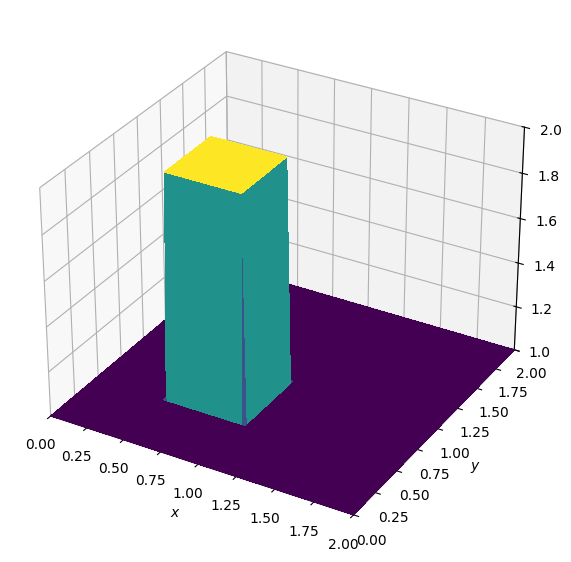

In [12]:
#NBVAL_IGNORE_OUTPUT
u_np = np.empty((nx, ny))
init_hat(field=u_np, dx=dx, dy=dy, value=2.)
plot_field(u_np)

## PETSc setup

The following cells configure the PETSc environment, imports, boundary subdomains, and shared grid. Both schemes reuse these.

In [13]:
# Environment variables are set in the first cell above.

In [14]:
from devito import (Grid, TimeFunction, Function, Eq,
                    Operator, switchconfig, configuration, SubDomain)
from devito.petsc import petscsolve, EssentialBC
from devito.petsc.initialize import PetscInitialize

PetscInitialize()

### Boundary subdomains

All four edges carry the Dirichlet condition $u = 1$, imposed on `u.forward` via `EssentialBC`.

In [15]:
class SubTop(SubDomain):
    name = 'subtop'
    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('right', 1)}

class SubBottom(SubDomain):
    name = 'subbottom'
    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('left', 1)}

class SubLeft(SubDomain):
    name = 'subleft'
    def define(self, dimensions):
        x, y = dimensions
        return {x: ('left', 1), y: ('middle', 1, 1)}

class SubRight(SubDomain):
    name = 'subright'
    def define(self, dimensions):
        x, y = dimensions
        return {x: ('right', 1), y: ('middle', 1, 1)}

sub1 = SubTop(); sub2 = SubBottom()
sub3 = SubLeft(); sub4 = SubRight()
subdomains = (sub1, sub2, sub3, sub4)

### Shared grid and boundary-value function

In [16]:
# float64 required by the PETSc build
grid = Grid(shape=(nx, ny), extent=(2., 2.),
            subdomains=subdomains, dtype=np.float64)

bc_val = Function(name='bc_val', grid=grid)
bc_val.data[:] = 1.

## Explicit scheme

The explicit discretisation evaluates the spatial terms at the **current** time level $n$:

$$\frac{u^{n+1}_{i,j} - u^n_{i,j}}{\Delta t} + c\frac{u^n_{i,j} - u^n_{i-1,j}}{\Delta x} + c\frac{u^n_{i,j} - u^n_{i,j-1}}{\Delta y} = 0$$

In symbolic form:
```python
Eq(u.dt + c*u.dxl + c*u.dyl, 0)
```
The Jacobian w.r.t. `u.forward` is $I/\Delta t$, so the KSP solve is trivially direct (converges in 1 iteration). Devito's `Operator` contains the full time loop — no Python loop required.

/home/zl5621/devito_original/devito/devito/symbolics/unevaluation.py:9: SymPyDeprecationWarning: 

Using non-Expr arguments in Mul is deprecated (in this case, one of
the arguments has type 'PetscInt').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#non-expr-args-deprecated
for details.

This has been deprecated since SymPy version 1.7. It
will be removed in a future version of SymPy.

  return cls.__base__.__new__(cls, *args, evaluate=False, **kwargs)
Operator `Kernel` ran in 0.06 s


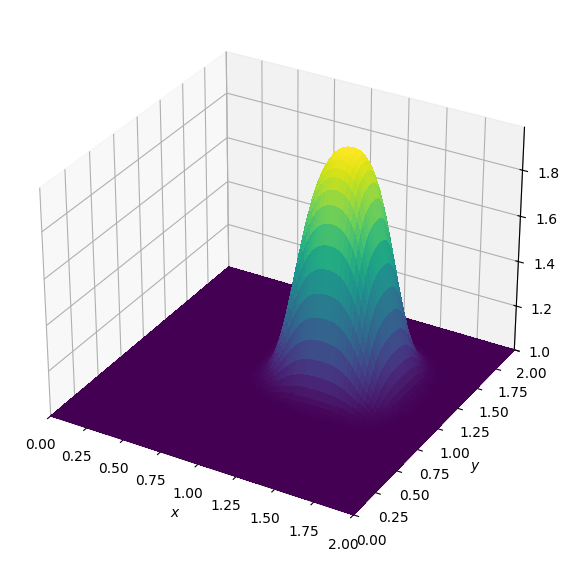

In [17]:
#NBVAL_IGNORE_OUTPUT
u_expl = TimeFunction(name='u_expl', grid=grid,
                      space_order=1, save=nt+1)

init_hat(field=u_expl.data[0], dx=dx, dy=dy, value=2.)
u_expl.data[0, 0, :]  = 1.;  u_expl.data[0, -1, :] = 1.
u_expl.data[0, :, 0]  = 1.;  u_expl.data[0, :, -1] = 1.

# Spatial terms at current time level (u.dxl, u.dyl)
eqn_expl = Eq(u_expl.dt + c*u_expl.dxl + c*u_expl.dyl, 0,
              subdomain=grid.interior)

bcs  = [EssentialBC(u_expl.forward, bc_val, subdomain=sub1)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub2)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub3)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub4)]

petsc_expl = petscsolve([eqn_expl] + bcs, target=u_expl.forward,
                        solver_parameters={'ksp_type': 'gmres',
                                           'ksp_rtol': 1e-6})
with switchconfig(language='petsc'):
    op_expl = Operator(petsc_expl)
    op_expl.apply(dt=dt)

plot_field(u_expl.data[nt].astype(float))

In [18]:
print(op_expl.ccode)

/* Devito generated code for Operator `Kernel` */

#define _POSIX_C_SOURCE 200809L
#define START(S) struct timeval start_ ## S , end_ ## S ; gettimeofday(&start_ ## S , NULL);
#define STOP(S,T) gettimeofday(&end_ ## S, NULL); T->S += (double)(end_ ## S .tv_sec-start_ ## S.tv_sec)+(double)(end_ ## S .tv_usec-start_ ## S .tv_usec)/1000000;

#include "stdlib.h"
#include "math.h"
#include "sys/time.h"
#include "petscsnes.h"
#include "petscdmda.h"
#include "xmmintrin.h"
#include "pmmintrin.h"

struct UserCtx0
{
  PetscScalar dt;
  PetscScalar h_x;
  PetscScalar h_y;
  PetscInt x_M;
  PetscInt x_ltkn0;
  PetscInt x_ltkn2;
  PetscInt x_m;
  PetscInt x_rtkn1;
  PetscInt x_rtkn2;
  PetscInt y_M;
  PetscInt y_ltkn1;
  PetscInt y_ltkn2;
  PetscInt y_m;
  PetscInt y_rtkn0;
  PetscInt y_rtkn2;
  struct dataobj * bc_val_vec;
  PetscInt time;
  struct dataobj * u_expl_vec;
} ;

struct dataobj
{
  void * data;
  PetscInt * size;
  unsigned long nbytes;
  unsigned long * npsize;
  unsigned long * dsize

## Implicit scheme

Moving the spatial terms to the **next** time level $n+1$ gives backward Euler — fully implicit:

$$\frac{u^{n+1}_{i,j} - u^n_{i,j}}{\Delta t} + c\frac{u^{n+1}_{i,j} - u^{n+1}_{i-1,j}}{\Delta x} + c\frac{u^{n+1}_{i,j} - u^{n+1}_{i,j-1}}{\Delta y} = 0$$

In symbolic form:
```python
Eq(u.dt + c*u.forward.dxl + c*u.forward.dyl, 0)
```
Compared to the explicit equation, only `u.dxl` → `u.forward.dxl` and `u.dyl` → `u.forward.dyl` change. The Jacobian is now non-trivial and GMRES is used to solve the system at each time step. Devito generates the matrix-free Jacobian routine and the Operator's internal time loop calls the KSP solver once per step.

/home/zl5621/devito_original/devito/devito/symbolics/unevaluation.py:9: SymPyDeprecationWarning: 

Using non-Expr arguments in Mul is deprecated (in this case, one of
the arguments has type 'PetscInt').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#non-expr-args-deprecated
for details.

This has been deprecated since SymPy version 1.7. It
will be removed in a future version of SymPy.

  return cls.__base__.__new__(cls, *args, evaluate=False, **kwargs)
Operator `Kernel` ran in 0.16 s


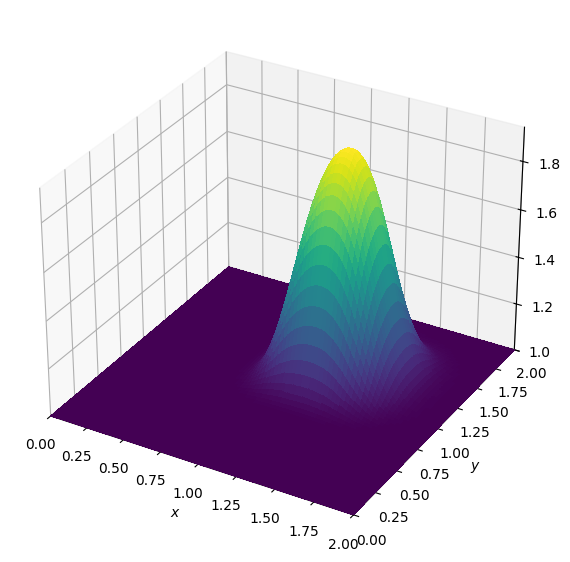

In [19]:
#NBVAL_IGNORE_OUTPUT
u_impl = TimeFunction(name='u_impl', grid=grid,
                      space_order=1, save=nt+1)

init_hat(field=u_impl.data[0], dx=dx, dy=dy, value=2.)
u_impl.data[0, 0, :]  = 1.;  u_impl.data[0, -1, :] = 1.
u_impl.data[0, :, 0]  = 1.;  u_impl.data[0, :, -1] = 1.

# Spatial terms at next time level (u.forward.dxl, u.forward.dyl)
eqn_impl = Eq(u_impl.dt + c*u_impl.forward.dxl + c*u_impl.forward.dyl, 0,
              subdomain=grid.interior)

bc_val = Function(name='bc_val', grid=grid)
bc_val.data[:] = 1.

bcs  = [EssentialBC(u_impl.forward, bc_val, subdomain=sub1)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub2)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub3)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub4)]

petsc_impl = petscsolve([eqn_impl] + bcs, target=u_impl.forward,
                        solver_parameters={'ksp_type': 'gmres',
                                           'ksp_rtol': 1e-6})


with switchconfig(language='petsc'):
    op_impl = Operator(petsc_impl)
    op_impl.apply(dt=dt)

plot_field(u_impl.data[nt].astype(float))

## Comparison

Both schemes produce similar results at $\sigma = 0.2$. The implicit scheme's advantage becomes clear when $\sigma > 1$: increasing `sigma` to e.g. 2 keeps the implicit solution stable while the explicit scheme diverges (the CFL condition is violated). Both are solved with the same PETSc/Devito machinery — only the time level of the spatial terms differs.